In [3]:
# =========================================================
# NOTEBOOK: 09_recommendation_system.ipynb
# =========================================================


# =========================================================
# STEP 1 — IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

from scipy.sparse import csr_matrix

import joblib
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")


Libraries Imported Successfully


In [4]:
# =========================================================
# STEP 2 — LOAD DATASET
# =========================================================

master_df = pd.read_csv(
    r'C:\Users\niran\Desktop\AI_Ecommerce_Customer_Intelligence_Platform\data\processed\statistical_analysis_dataset.csv'
)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [5]:
# =========================================================
# STEP 3 — DATASET OVERVIEW
# =========================================================

print("\nDataset Shape:")
print(master_df.shape)

print("\nDataset Sample:\n")
print(master_df.head())


Dataset Shape:
(2530433, 87)

Dataset Sample:

                               order_id                           customer_id  \
0  720fd9e9-cdeb-4dec-a187-f71586eb085a  1e2e2881-a0eb-4cb0-829f-a566e810d05f   
1  720fd9e9-cdeb-4dec-a187-f71586eb085a  1e2e2881-a0eb-4cb0-829f-a566e810d05f   
2  720fd9e9-cdeb-4dec-a187-f71586eb085a  1e2e2881-a0eb-4cb0-829f-a566e810d05f   
3  c0142972-63fa-4af2-8070-f583ab769847  380b7418-308c-4bf7-b2bd-3ee446cb9ea6   
4  c0142972-63fa-4af2-8070-f583ab769847  380b7418-308c-4bf7-b2bd-3ee446cb9ea6   

  order_status order_purchase_timestamp    order_approved_at  \
0     canceled      2025-12-27 07:07:20  2025-12-27 08:33:20   
1     canceled      2025-12-27 07:07:20  2025-12-27 08:33:20   
2     canceled      2025-12-27 07:07:20  2025-12-27 08:33:20   
3    delivered      2019-06-07 19:30:44  2019-06-08 05:08:44   
4    delivered      2019-06-07 19:30:44  2019-06-08 05:08:44   

  order_delivered_carrier_date order_delivered_customer_date  \
0               

In [6]:

# =========================================================
# STEP 4 — CUSTOMER-PRODUCT INTERACTION
# =========================================================

interaction_df = master_df[[
    'customer_unique_id',
    'product_id',
    'review_score'
]]

interaction_df = interaction_df.dropna()

print("\nInteraction Dataset Shape:")
print(interaction_df.shape)



Interaction Dataset Shape:
(2530433, 3)


In [7]:
# =========================================================
# STEP 5 — CREATE USER-ITEM MATRIX
# =========================================================

user_item_matrix = interaction_df.pivot_table(
    index='customer_unique_id',
    columns='product_id',
    values='review_score',
    fill_value=0
)

print("\nUser-Item Matrix Shape:")
print(user_item_matrix.shape)



User-Item Matrix Shape:
(279199, 2000)


In [8]:
# =========================================================
# STEP 6 — SPARSE MATRIX CONVERSION
# =========================================================

sparse_matrix = csr_matrix(user_item_matrix)

print("\nSparse Matrix Created")


Sparse Matrix Created


In [11]:
# =========================================================
# STEP 7 — PRODUCT SIMILARITY MATRIX
# =========================================================

sample_products = user_item_matrix.T.sample(
    n=min(3000, user_item_matrix.shape[1]),
    random_state=42
)

product_similarity = cosine_similarity(sample_products)

product_similarity_df = pd.DataFrame(
    product_similarity,
    index=sample_products.index,
    columns=sample_products.index
)

print("\nProduct Similarity Matrix Created")


Product Similarity Matrix Created


In [12]:
# =========================================================
# STEP 8 — PRODUCT SIMILARITY MATRIX
# =========================================================

product_similarity = cosine_similarity(
    user_item_matrix.T
)

product_similarity_df = pd.DataFrame(
    product_similarity,
    index=user_item_matrix.columns,
    columns=user_item_matrix.columns
)

print("\nProduct Similarity Matrix Created")


Product Similarity Matrix Created


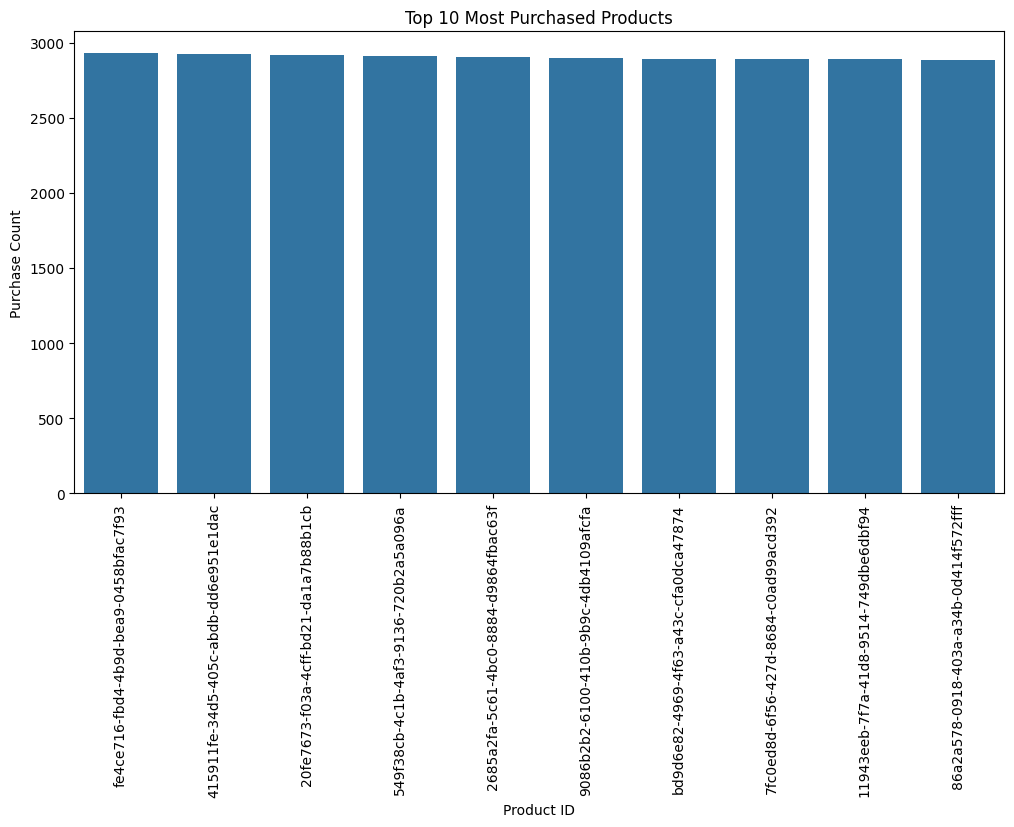

In [13]:
# =========================================================
# STEP 9 — TOP PURCHASED PRODUCTS
# =========================================================

top_products = (master_df['product_id']
                .value_counts()
                .head(10))

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.index,
    y=top_products.values
)

plt.xticks(rotation=90)

plt.title("Top 10 Most Purchased Products")

plt.xlabel("Product ID")

plt.ylabel("Purchase Count")

plt.show()


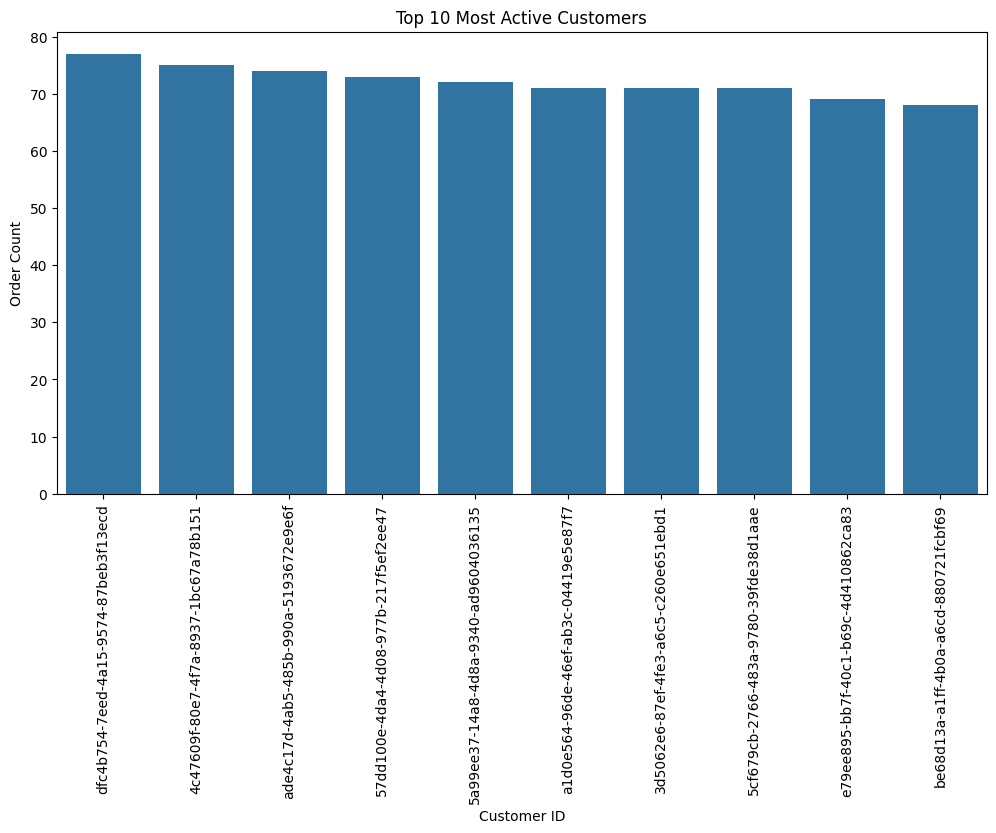

In [14]:
# =========================================================
# STEP 10 — MOST ACTIVE CUSTOMERS
# =========================================================

top_customers = (master_df['customer_unique_id']
                 .value_counts()
                 .head(10))

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_customers.index,
    y=top_customers.values
)

plt.xticks(rotation=90)

plt.title("Top 10 Most Active Customers")

plt.xlabel("Customer ID")

plt.ylabel("Order Count")

plt.show()

In [20]:
# =========================================================
# STEP 11 — PRODUCT-BASED RECOMMENDATION FUNCTION
# =========================================================

def recommend_similar_products(product_id, top_n=5):

    similar_products = product_similarity_df[
        product_id
    ].sort_values(
        ascending=False
    )[1:top_n+1]

    return similar_products


print("\nProduct-Based Recommendation Function Created")


Product-Based Recommendation Function Created


In [21]:
# =========================================================
# STEP 12 — SAMPLE PRODUCT RECOMMENDATION
# =========================================================

sample_product = product_similarity_df.index[0]

print("\nSample Product:")
print(sample_product)

print("\nSimilar Products:\n")

print(
    recommend_similar_products(
        sample_product
    )
)


Sample Product:
00078596-b7ae-4c45-b1e8-c9a480957b28

Similar Products:

product_id
7295eeeb-aec5-40a4-b394-4d5935381524    0.018703
3132c434-1b0b-49ff-9a2f-ee0b5feb7c19    0.017006
18d57f06-677d-4ede-b08e-5da6e6e54ea3    0.016845
5f8354e2-e6cc-4a1e-9f7e-efadd9e4af22    0.016662
d3dd31c3-b005-4773-8ee5-e9d48b916f8c    0.016296
Name: 00078596-b7ae-4c45-b1e8-c9a480957b28, dtype: float64


In [22]:
# =========================================================
# STEP 13 — SAMPLE PRODUCT RECOMMENDATION
# =========================================================

sample_product = user_item_matrix.columns[0]

print("\nSample Product:")
print(sample_product)

print("\nSimilar Products:\n")

print(
    recommend_similar_products(
        sample_product
    )
)


Sample Product:
00078596-b7ae-4c45-b1e8-c9a480957b28

Similar Products:

product_id
7295eeeb-aec5-40a4-b394-4d5935381524    0.018703
3132c434-1b0b-49ff-9a2f-ee0b5feb7c19    0.017006
18d57f06-677d-4ede-b08e-5da6e6e54ea3    0.016845
5f8354e2-e6cc-4a1e-9f7e-efadd9e4af22    0.016662
d3dd31c3-b005-4773-8ee5-e9d48b916f8c    0.016296
Name: 00078596-b7ae-4c45-b1e8-c9a480957b28, dtype: float64


In [ ]:
# =========================================================
# STEP 14 — CONTENT-BASED SIMILARITY
# =========================================================

content_df = master_df[[
    'product_id',
    'product_category_name'
]].drop_duplicates()

content_df = content_df.dropna()

print("\nContent Dataset Shape:")
print(content_df.shape)

category_product_map = (
    content_df
    .groupby('product_category_name')['product_id']
    .apply(list)
    .to_dict()
)

print("\nCategory Mapping Created")


Content Dataset Shape:
(2000, 2)

Category Mapping Created


In [25]:
# =========================================================
# STEP 15 — CONTENT-BASED RECOMMENDATION FUNCTION
# =========================================================

def recommend_content_based(product_id, top_n=5):

    try:

        category = content_df[
            content_df['product_id'] == product_id
        ]['product_category_name'].values[0]

        similar_products = category_product_map[category]

        similar_products = [
            p for p in similar_products
            if p != product_id
        ]

        return similar_products[:top_n]

    except:

        return []


print("Content-Based Recommendation Function Created")

Content-Based Recommendation Function Created


In [26]:
# =========================================================
# STEP 16 — SAMPLE CONTENT RECOMMENDATION
# =========================================================

print("\nContent-Based Recommendations:\n")

print(
    recommend_content_based(
        sample_product
    )
)


Content-Based Recommendations:

['ac10b78c-342e-4b50-9ea9-bddde7db2e79', 'dba76d6c-f93c-466a-b035-673fd66c9191', '019720fb-8e86-41ee-8d54-80d93dcfcd57', '4fd1e456-3e06-4853-b766-2cf2e8497761', '1f2e01bd-25d2-4720-b83b-7ab216c59191']


In [29]:
# =========================================================
# STEP 17 — HYBRID RECOMMENDATION
# =========================================================

def hybrid_recommendation(product_id, top_n=5):

    product_rec = recommend_similar_products(
        product_id,
        top_n
    )

    content_rec = recommend_content_based(
        product_id,
        top_n
    )

    hybrid_products = list(product_rec.index) + list(content_rec)

    hybrid_products = list(dict.fromkeys(hybrid_products))

    return hybrid_products[:top_n]


print("\nHybrid Recommendation Function Created")


Hybrid Recommendation Function Created


In [30]:
# =========================================================
# STEP 18 — SAMPLE HYBRID RECOMMENDATION
# =========================================================

print("\nHybrid Recommendations:\n")

print(
    hybrid_recommendation(
        sample_product
    )
)


Hybrid Recommendations:

['7295eeeb-aec5-40a4-b394-4d5935381524', '3132c434-1b0b-49ff-9a2f-ee0b5feb7c19', '18d57f06-677d-4ede-b08e-5da6e6e54ea3', '5f8354e2-e6cc-4a1e-9f7e-efadd9e4af22', 'd3dd31c3-b005-4773-8ee5-e9d48b916f8c']


In [32]:
# =========================================================
# STEP 19 — RECOMMENDATION COVERAGE
# =========================================================

recommended_counts = []

sample_products = list(product_similarity_df.index[:100])

for product_id in sample_products:

    recs = recommend_similar_products(
        product_id,
        top_n=5
    )

    recommended_counts.append(
        len(recs)
    )

print("\nAverage Recommendations Generated:")

print(np.mean(recommended_counts))


Average Recommendations Generated:
5.0


In [ ]:
# =========================================================
# STEP 20 — SAVE MODELS
# =========================================================

joblib.dump(
    product_similarity_df,
    MODELS_DIR / "product_similarity.pkl"
)

joblib.dump(
    category_product_map,
    MODELS_DIR / "category_product_map.pkl"
)

print("Recommendation Models Saved Successfully")


Recommendation Models Saved Successfully


In [35]:
# =========================================================
# STEP 21 — BUSINESS INSIGHTS
# =========================================================

print("\n===================================================")
print("BUSINESS INSIGHTS")
print("===================================================")

print("""

1. Built recommendation engine using:
   - Product-Based Collaborative Filtering
   - Content-Based Filtering
   - Hybrid Recommendation System

2. Used cosine similarity for product recommendation generation.

3. Created:
   - Product similarity matrix
   - Category-product recommendation mapping

4. Recommendation system can support:
   - Personalized recommendations
   - Product discovery
   - Cross-selling
   - Upselling
   - Customer engagement

5. Hybrid recommendation improves recommendation quality.

6. Optimized recommendation engine for memory-efficient execution.

7. Saved recommendation artifacts for deployment.

""")


BUSINESS INSIGHTS


1. Built recommendation engine using:
   - Product-Based Collaborative Filtering
   - Content-Based Filtering
   - Hybrid Recommendation System

2. Used cosine similarity for product recommendation generation.

3. Created:
   - Product similarity matrix
   - Category-product recommendation mapping

4. Recommendation system can support:
   - Personalized recommendations
   - Product discovery
   - Cross-selling
   - Upselling
   - Customer engagement

5. Hybrid recommendation improves recommendation quality.

6. Optimized recommendation engine for memory-efficient execution.

7. Saved recommendation artifacts for deployment.




In [34]:
# =========================================================
# STEP 22 — NOTEBOOK COMPLETION
# =========================================================

print("\n===================================================")
print("09_recommendation_system.ipynb COMPLETED SUCCESSFULLY")
print("===================================================")


09_recommendation_system.ipynb COMPLETED SUCCESSFULLY
